In [1]:
import sqlite3 as sql
import pandas as pd

In [2]:
#connection
conn = sql.connect('database.sqlite')
conn

In [3]:
a = conn.execute('select * from Salaries')
a

In [4]:
pd.read_sql_query('select * from sqlite_master',conn)

,type,name,tbl_name,rootpage,sql
0,table,Salaries,Salaries,2,CREATE TABLE Salaries (\n Id INTEGER PRIMAR...
1,index,salaries_year_idx,Salaries,16566,CREATE INDEX salaries_year_idx ON Salaries (Year)


In [5]:
pd.read_sql_query('select * from Salaries',conn)

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0,400184.25,,567595.43,567595.43,2011,,San Francisco,
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,,538909.28,538909.28,2011,,San Francisco,
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,,335279.91,335279.91,2011,,San Francisco,
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916,56120.71,198306.9,,332343.61,332343.61,2011,,San Francisco,
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737,182234.59,,326373.19,326373.19,2011,,San Francisco,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148649,148650,Roy I Tillery,Custodian,0,0,0,0,0.00,0.00,2014,,San Francisco,PT
148650,148651,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,
148651,148652,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,
148652,148653,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,


In [6]:
def sql_query(q):
    return pd.read_sql_query(q,conn)

In [7]:
q = '''select * from Salaries'''
sql_query(q)

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0,400184.25,,567595.43,567595.43,2011,,San Francisco,
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,,538909.28,538909.28,2011,,San Francisco,
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,,335279.91,335279.91,2011,,San Francisco,
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916,56120.71,198306.9,,332343.61,332343.61,2011,,San Francisco,
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737,182234.59,,326373.19,326373.19,2011,,San Francisco,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148649,148650,Roy I Tillery,Custodian,0,0,0,0,0.00,0.00,2014,,San Francisco,PT
148650,148651,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,
148651,148652,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,
148652,148653,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,


1. What is the average TotalPayBenefits for each JobTitle? exclude ('Not Provided', 'Not provided')

In [8]:
q ='''select 
    jobtitle, 
    avg(cast(totalpaybenefits as float)) as average_totalpaybenefits     
from 
    salaries
where 
    totalpaybenefits not in ('not provided', 'not Provided')
group by 
    jobtitle
order by 
    average_totalpaybenefits desc'''

sql_query(q)

,JobTitle,average_totalpaybenefits
0,Chief Investment Officer,436224.360000
1,Chief of Police,411732.266667
2,"Chief, Fire Department",408865.326667
3,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,399211.275000
4,"Gen Mgr, Public Trnsp Dept",380696.440000
...,...,...
2154,"BOARD/COMMISSION MEMBER, GROUP III",638.787879
2155,"BdComm Mbr, Grp2,M=$25/Mtg",475.047742
2156,"BOARD/COMMISSION MEMBER, GROUP II",296.511628
2157,PUBLIC SAFETY COMMUNICATIONS TECHNICIAN,149.510000


2. Which JobTitle has the most employees in each year? exclude ('Not Provided', 'Not provided')

In [39]:
q = '''select 
    year, 
    jobtitle, 
    count(*) as employee_count
    from 
    salaries
    where 
    jobtitle not in ('not provided', 'not Provided')
    group by 
    year, jobtitle
    order by 
    year, employee_count desc'''

sql_query(q)


,Year,JobTitle,employee_count
0,2011,TRANSIT OPERATOR,2388
1,2011,SPECIAL NURSE,1402
2,2011,REGISTERED NURSE,1219
3,2011,CUSTODIAN,796
4,2011,FIREFIGHTER,794
...,...,...,...
4132,2014,"Administrator, DPH",1
4133,2014,Administrative Hearing Sup,1
4134,2014,"Adm, SFGH Medical Center",1
4135,2014,Acupuncturist,1


3. What is the total number of unique employees? exclude ('Not Provided', 'Not provided')

In [17]:
pd.read_sql_query("pragma table_info(salaries);", conn)


,cid,name,type,notnull,dflt_value,pk
0,0,Id,INTEGER,0,None,1
1,1,EmployeeName,TEXT,0,None,0
2,2,JobTitle,TEXT,0,None,0
3,3,BasePay,NUMERIC,0,None,0
4,4,OvertimePay,NUMERIC,0,None,0
5,5,OtherPay,NUMERIC,0,None,0
6,6,Benefits,NUMERIC,0,None,0
7,7,TotalPay,NUMERIC,0,None,0
8,8,TotalPayBenefits,NUMERIC,0,None,0
9,9,Year,INTEGER,0,None,0


In [18]:
q = """
select 
    count(distinct employeename) as unique_employee_count
from 
    salaries
where 
    employeename not in ('not provided', 'Not Provided');
"""


sql_query(q)

,unique_employee_count
0,110810


4. Show All Employees Ordered By Their TotalPayBenefits In Descending Order? exclude ('Not Provided', 'Not provided')

In [19]:
q = """
select 
    employeename, 
    jobtitle, 
    totalpaybenefits
from 
    salaries
where 
    totalpaybenefits not in ('not provided', 'Not Provided')
order by 
    cast(totalpaybenefits as float) desc;
"""

sql_query(q)

,EmployeeName,JobTitle,TotalPayBenefits
0,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,567595.43
1,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),538909.28
2,David Shinn,Deputy Chief 3,510732.68
3,Amy P Hart,Asst Med Examiner,479652.21
4,William J Coaker Jr.,Chief Investment Officer,436224.36
...,...,...,...
148649,Not provided,Not provided,0.00
148650,Timothy E Gibson,Police Officer 3,-2.73
148651,Mark E Laherty,Police Officer 3,-8.20
148652,David P Kucia,Police Officer 3,-33.89


5. Show All Employees With A TotalPaybenefits Value Between 125,000 and 150,000 And A Job Title 'Firefighter'? exclude ('Not Provided', 'Not provided')

In [20]:
q = """
select 
    employeename, 
    jobtitle, 
    totalpaybenefits
from 
    salaries
where 
    jobtitle = 'firefighter'
    and totalpaybenefits not in ('not provided', 'Not Provided')
    and cast(totalpaybenefits as float) between 125000 and 150000
order by 
    cast(totalpaybenefits as float) desc;
"""

sql_query(q)

,EmployeeName,JobTitle,TotalPayBenefits


6. How many employees have no overtime pay or other pay? exclude ('Not Provided', 'Not provided')


In [21]:
q = """
select 
    count(*) as no_extra_pay_employees
from 
    salaries
where 
    overtimepay not in ('not provided', 'Not Provided')
    and otherpay not in ('not provided', 'Not Provided')
    and cast(overtimepay as float) = 0
    and cast(otherpay as float) = 0;
"""


sql_query(q)

,no_extra_pay_employees
0,34655


7. Show top 10 employees having (overtimepay+OtherPay) in bar plot?  exclude ('Not Provided', 'Not provided')

In [28]:
q = """
select 
    employeename, 
    cast(overtimepay as float) + cast(otherpay as float) as extra_pay
from 
    salaries
where 
    overtimepay not in ('not provided', 'Not Provided')
    and otherpay not in ('not provided', 'Not Provided')
order by 
    extra_pay desc
limit 10;
"""

# Save SQL result to a DataFrame
df = pd.read_sql_query(q, conn)
df

,EmployeeName,extra_pay
0,NATHANIEL FORD,400184.25
1,GARY JIMENEZ,382943.26
2,David Shinn,342802.63
3,CHRISTOPHER CHONG,254427.61
4,John Goldberg,245999.41
5,Gary Altenberg,234035.79
6,Khoa Trinh,224472.73
7,ALSON LEE,223489.04
8,Brendan A Ward,216637.92
9,Whitney P Yee,213311.84


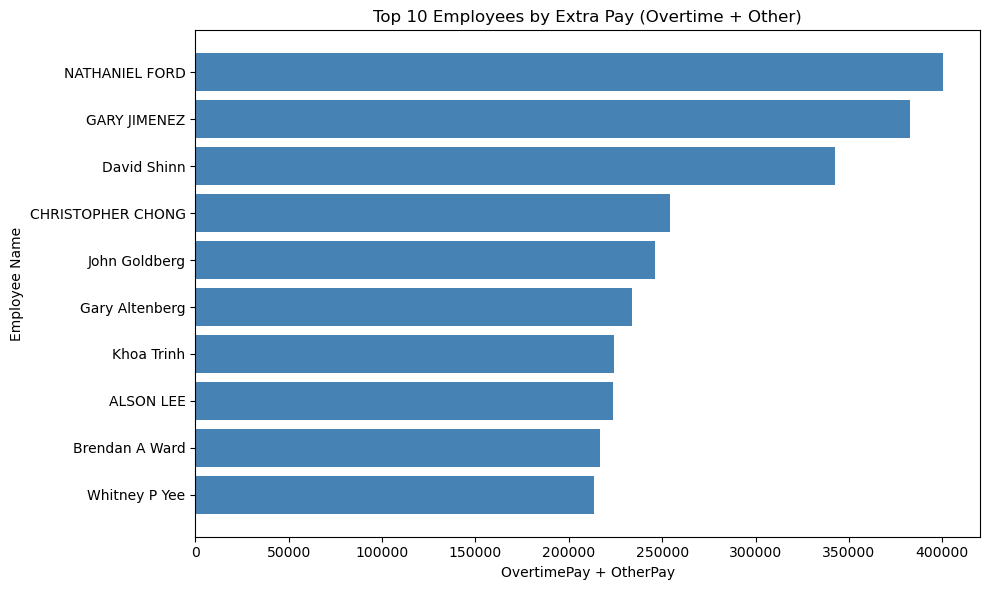

In [29]:

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(df['EmployeeName'], df['extra_pay'], color='steelblue')
plt.xlabel('OvertimePay + OtherPay')
plt.ylabel('Employee Name')
plt.title('Top 10 Employees by Extra Pay (Overtime + Other)')
plt.gca().invert_yaxis()  # Highest at the top
plt.tight_layout()
plt.show()


8. Show The Average of BasePay, OverTime, OtherPay for all employees in pie chart? exclude ('Not Provided', 'Not provided')


In [31]:
q = """
SELECT 
    AVG(CAST(basepay AS FLOAT)) AS avg_basepay,
    AVG(CAST(overtimepay AS FLOAT)) AS avg_overtimepay,
    AVG(CAST(otherpay AS FLOAT)) AS avg_otherpay
FROM 
    salaries
WHERE 
    basepay NOT IN ('Not Provided', 'not provided') AND
    overtimepay NOT IN ('Not Provided', 'not provided') AND
    otherpay NOT IN ('Not Provided', 'not provided');
"""

# Run the query
avg_df = pd.read_sql_query(q, conn)
avg_df

,avg_basepay,avg_overtimepay,avg_otherpay
0,66055.506718,5066.059886,3648.767297


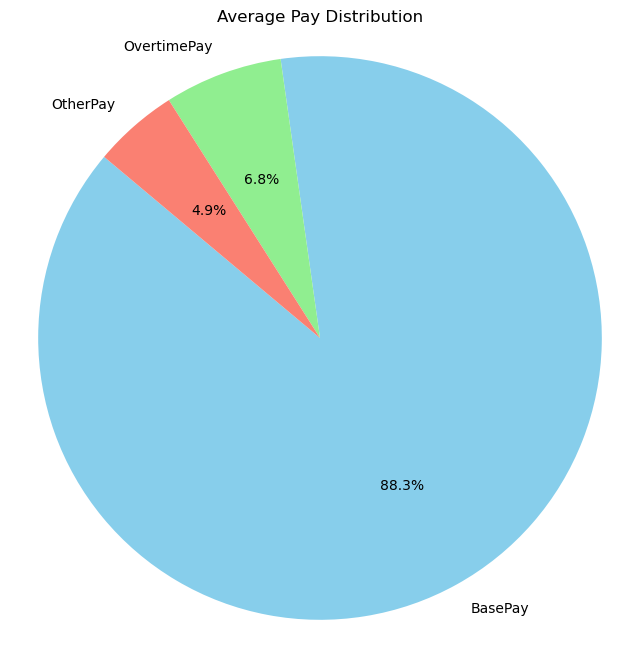

In [32]:
import matplotlib.pyplot as plt

# Extract values
labels = ['BasePay', 'OvertimePay', 'OtherPay']
values = [avg_df['avg_basepay'][0], avg_df['avg_overtimepay'][0], avg_df['avg_otherpay'][0]]

# Plot
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightgreen', 'salmon'])
plt.title('Average Pay Distribution')
plt.axis('equal')  # Circle shape
plt.show()

9. Get the average TotalPayBenefits for each JobTitle, but only for those with an average pay greater than 75000? exclude ('Not Provided', 'Not provided')


In [37]:
q = '''SELECT 
    jobtitle, 
    AVG(CAST(totalpaybenefits AS FLOAT)) AS Avg_TotalPayBenefits
FROM 
    salaries
WHERE 
    totalpaybenefits NOT IN ('Not Provided', 'not provided')
GROUP BY 
    jobtitle
HAVING 
    Avg_TotalPayBenefits > 75000
ORDER BY 
    Avg_TotalPayBenefits DESC;

'''
sql_query(q)

,JobTitle,Avg_TotalPayBenefits
0,Chief Investment Officer,436224.360000
1,Chief of Police,411732.266667
2,"Chief, Fire Department",408865.326667
3,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,399211.275000
4,"Gen Mgr, Public Trnsp Dept",380696.440000
...,...,...
1432,"OPERATING ENGINEER, UNIVERSAL",75273.754200
1433,CABLE SPLICER,75255.005833
1434,Community Development Asst,75246.657391
1435,Senior Legal Process Clerk,75108.724532


10. Get the number of employees (EmployeeName) for each JobTitle, where the count is greater than 10?  exclude ('Not Provided', 'Not provided')


In [36]:
q = '''SELECT 
    jobtitle, 
    COUNT(employeename) AS EmployeeCount
FROM 
    salaries
WHERE 
    jobtitle NOT IN ('Not Provided', 'not provided')
GROUP BY 
    jobtitle
HAVING 
    COUNT(employeename) > 10
ORDER BY 
    EmployeeCount DESC;
'''

sql_query(q)

,JobTitle,EmployeeCount
0,Transit Operator,7036
1,Special Nurse,4389
2,Registered Nurse,3736
3,Public Svc Aide-Public Works,2518
4,Police Officer 3,2421
...,...,...
1151,AUTOMOTIVE MECHANIC ASSISTANT SUPERVISOR,11
1152,ASSOCIATE PERFORMANCE AUDITOR,11
1153,ASSISTANT ELECTRONIC MAINTENANCE TECHNICIAN,11
1154,ARTS PROGRAM ASSISTANT,11
